# Importing modules and settings

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
from matplotlib.pyplot import rc_context

In [ ]:
umap_cmap = sb.blend_palette(['xkcd:light grey', 'xkcd:medium blue'], as_cmap = True)

In [ ]:
score_cmap = sb.blend_palette(['whitesmoke', 'lightgray', 'lightcoral', 'red'], as_cmap = True)

General settings of Scanpy

In [ ]:
sc.settings.verbosity = 4
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.9.1 anndata==0.9.1 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.4.2 scikit-learn==1.0.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


# Declaring the input and output files

In [ ]:
adata = sc.read_h5ad('../1 Matrix Preprocessing/Serotonergic_data_annotated.h5ad')

In [ ]:
adata.var_names

Index(['h1SMcG0000008', 'h1SMcG0000009', 'h1SMcG0000011', 'h1SMcG0000012',
       'h1SMcG0000013', 'h1SMcG0000014', 'h1SMcG0000015', 'h1SMcG0000016',
       'h1SMcG0000017', 'h1SMcG0000021',
       ...
       'h1SMnG0034431', 'h1SMnG0034440', 'h1SMnG0034840', 'h1SMnG0034892',
       'h1SMnG0034949', 'h1SMnG0034970', 'h1SMnG0035064', 'h1SMnG0035227',
       'h1SMnG0035258', 'h1SMnG0035302'],
      dtype='object', length=24000)

In [ ]:
adata.var

,gene_ids,feature_types,longest_isoform,gene_type,gene_JakkeGuo,gene_Jakke_ver1,gene_ddv6,jakkeguo_collapsed,jakke_ver1_collapsed,ddv6_collapsed,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
h1SMcG0000008,h1SMcG0000008,Gene Expression,h1SMcT0000008.1,hconf,SMEST029651001.1,SMEST029651001.1,dd_Smed_v6_35379_0_1,"SMEST029651001.1,SMEST029651002.1,SmMSTRG.9911...","SMEST029651001.1,SMEST029651002.1",dd_Smed_v6_35379_0_1,...,10,0.000232,99.978886,11.0,True,0.000284,0.477953,1.455614,0.000172,0.012502
h1SMcG0000009,h1SMcG0000009,Gene Expression,h1SMcT0000009.2,hconf,SMEST029652002.1,SMEST029652002.1,dd_Smed_v6_5323_0_1,"SMEST029652002.1,SmMSTRG.9914.2,SmMSTRG.9914.3...",SMEST029652002.1,dd_Smed_v6_5323_0_1,...,196,0.004159,99.586175,197.0,True,0.003342,0.036366,0.147434,0.002345,0.039136
h1SMcG0000011,h1SMcG0000011,Gene Expression,h1SMcT0000011.1,hconf,SMEST029655001.1,SMEST029655001.1,dd_Smed_v6_6416_0_1,"SMEST029655001.1,SMEST029655002.1,SmMSTRG.9916...","SMEST029655001.1,SMEST029655002.1",dd_Smed_v6_6416_0_1,...,2366,0.053312,95.004539,2525.0,True,0.044958,0.140558,0.456098,0.031060,0.146029
h1SMcG0000012,h1SMcG0000012,Gene Expression,h1SMcT0000012.1,hconf,SmMSTRG.9913.2,SMEST029666001.1,dd_Smed_v6_20296_0_1,"SMEST029666001.1,SmMSTRG.9913.2",SMEST029666001.1,dd_Smed_v6_20296_0_1,...,25,0.000549,99.947216,26.0,True,0.000470,0.185634,0.589633,0.000318,0.015024
h1SMcG0000013,h1SMcG0000013,Gene Expression,h1SMcT0000013.5,hconf,SmMSTRG.9917.1,MSTRG.9917.1,dd_Smed_v6_4708_0_1,"SMEST029667004.1,SmMSTRG.9917.1,SmMSTRG.9917.2...","MSTRG.9917.1,SMEST029667004.1",dd_Smed_v6_4708_0_1,...,681,0.014885,98.562169,705.0,True,0.012562,0.100089,0.336211,0.008670,0.077038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h1SMnG0034970,h1SMnG0034970,Gene Expression,h1SMnT0034970.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000040,0.120145,0.395626,0.000027,0.004380
h1SMnG0035064,h1SMnG0035064,Gene Expression,h1SMnT0035064.1,other,-,-,-,-,-,-,...,1,0.000021,99.997889,1.0,True,0.000026,0.225550,0.707884,0.000017,0.003735
h1SMnG0035227,h1SMnG0035227,Gene Expression,h1SMnT0035227.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000049,0.321466,0.992030,0.000031,0.005060
h1SMnG0035258,h1SMnG0035258,Gene Expression,h1SMnT0035258.1,hconf,-,-,-,-,-,-,...,3,0.000063,99.993666,3.0,True,0.000092,0.375602,1.152403,0.000057,0.007119


In [ ]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,0.0,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0.0,0,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,0.0,4,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,0.0,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,0.0,7,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,0.0,0,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,0.0,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons


In [ ]:
adata

AnnData object with n_obs × n_vars = 47292 × 24000
    obs: 'sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio', 'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'ingest_names', 'transferred', 'leiden_3_names_collapsed', 'leiden_3_names', 'broad_names'
    var: 'gene_ids', 'feature_types', 'longest_isoform', 'gene_type', 'gene_JakkeGuo', 'gene_Jakke_ver1', 'gene_ddv6', 'jakkeguo_collapsed', 'jakke_ver1_collapsed', 'ddv6_collapsed', 'Preferred_name', 'Description', 'PFAMs', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'biological_replicates', 'dendrogram_leiden_1', 'dendrogram_leiden_2', 'dendrogram_leiden_3', 'dendrogram_leiden_4', 'hvg', 'ingest_names_colors', 'leiden', 'leiden_1_colors', 'leiden_2_colors', 'leiden_

In [ ]:
clusteringlayer = 'leiden_3_names'

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


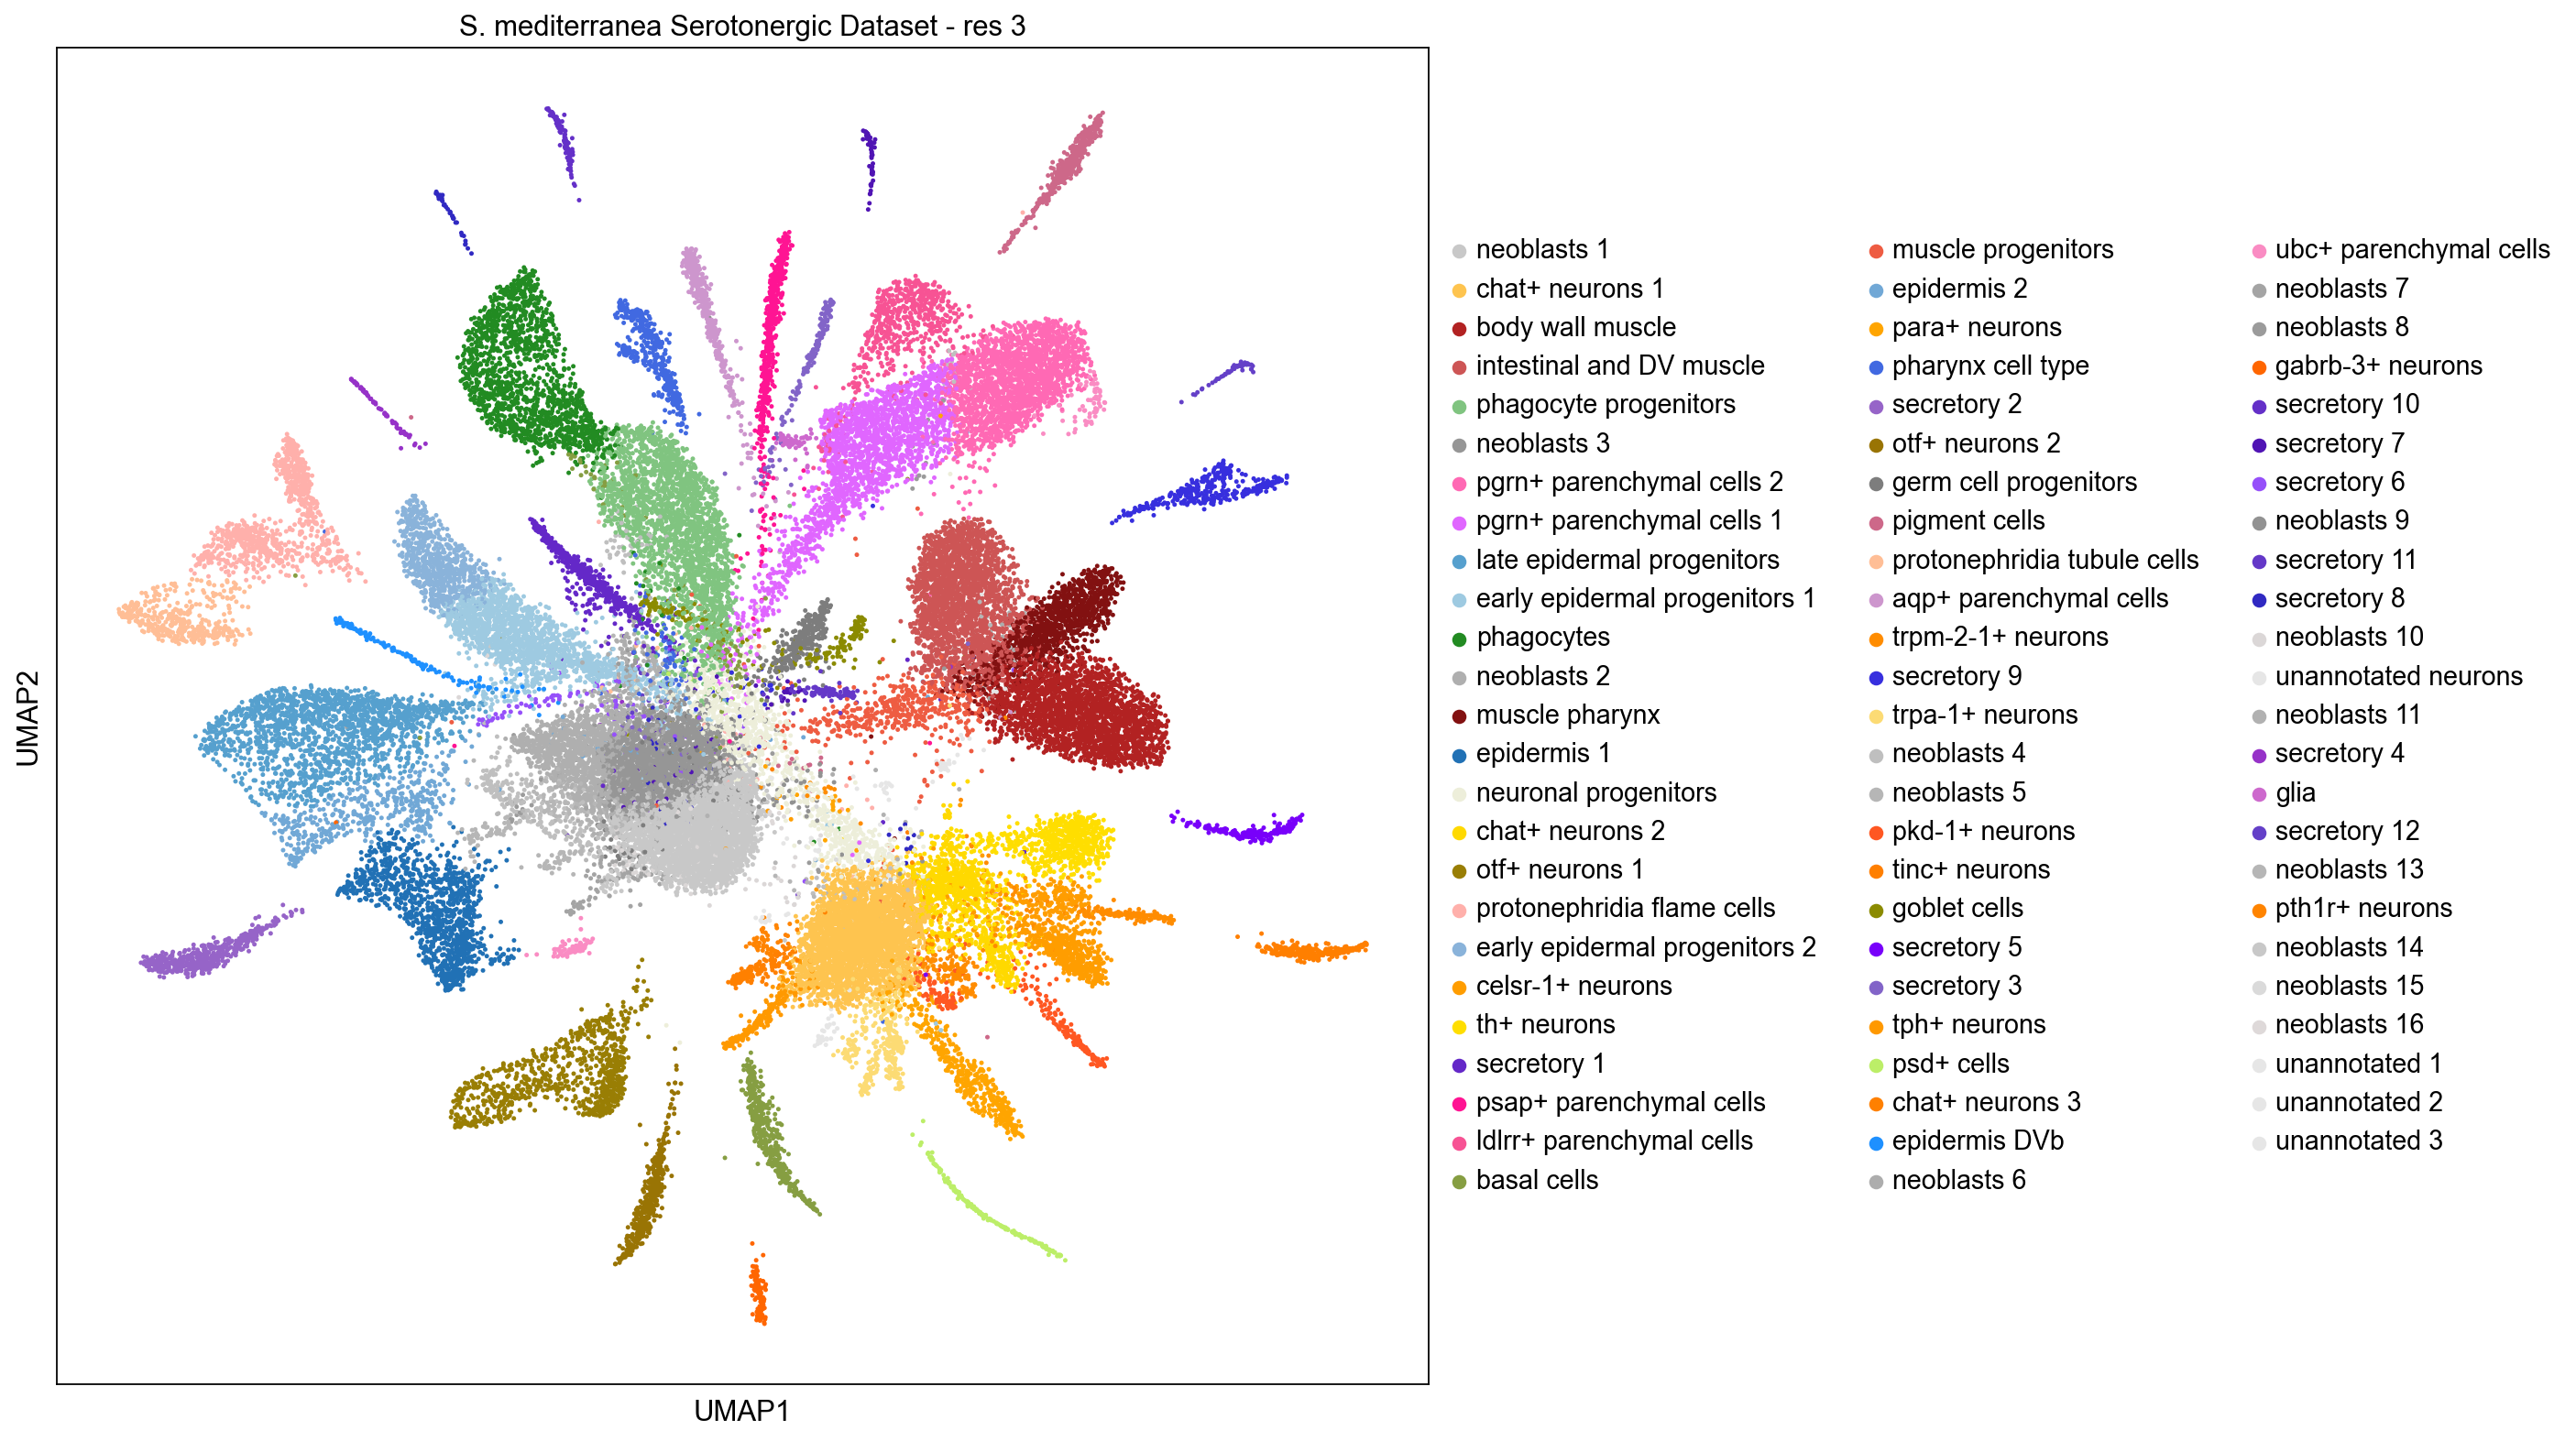

In [ ]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color=clusteringlayer, legend_fontoutline = 5,
        title= 'S. mediterranea Serotonergic Dataset - res 3', size = 20,
        frameon=True, add_outline = False)

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


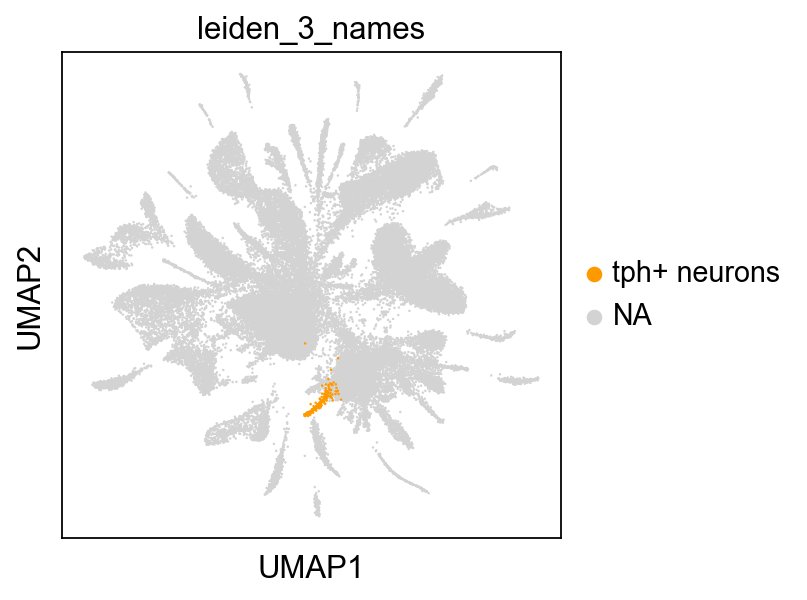

In [ ]:
sc.pl.umap(adata, color= clusteringlayer, size = 5, groups =
           ['tph+ neurons'])

**smed_genes_annotated_with_glutamate_GOs**

In [ ]:
glutamate_GOs = ["h1SMcG0000485",
"h1SMcG0000830",
"h1SMcG0000954",
"h1SMcG0001384",
"h1SMcG0001404",
"h1SMcG0001888",
"h1SMcG0002222",
"h1SMcG0002232",
"h1SMcG0002319",
"h1SMcG0002454",
"h1SMcG0003214",
"h1SMcG0003952",
"h1SMcG0004202",
"h1SMcG0004370",
"h1SMcG0004388",
"h1SMcG0004514",
"h1SMcG0004841",
"h1SMcG0005040",
"h1SMcG0005085",
"h1SMcG0005214",
"h1SMcG0005948",
"h1SMcG0005950",
"h1SMcG0005951",
"h1SMcG0005986",
"h1SMcG0006087",
"h1SMcG0006353",
"h1SMcG0006428",
"h1SMcG0007044",
"h1SMcG0007449",
"h1SMcG0007451",
"h1SMcG0008182",
"h1SMcG0008504",
"h1SMcG0008684",
"h1SMcG0008858",
"h1SMcG0009207",
"h1SMcG0009669",
"h1SMcG0009810",
"h1SMcG0009932",
"h1SMcG0010426",
"h1SMcG0010517",
"h1SMcG0010565",
"h1SMcG0011415",
"h1SMcG0011755",
"h1SMcG0011865",
"h1SMcG0012274",
"h1SMcG0012533",
"h1SMcG0012570",
"h1SMcG0012762",
"h1SMcG0012829",
"h1SMcG0013277",
"h1SMcG0013289",
"h1SMcG0013291",
"h1SMcG0013301",
"h1SMcG0013358",
"h1SMcG0014164",
"h1SMcG0014743",
"h1SMcG0015178",
"h1SMcG0015342",
"h1SMcG0015771",
"h1SMcG0016744",
"h1SMcG0016889",
"h1SMcG0017037",
"h1SMcG0017038",
"h1SMcG0017159",
"h1SMcG0017174",
"h1SMcG0017259",
"h1SMcG0017641",
"h1SMcG0017834",
"h1SMcG0017880",
"h1SMcG0017923",
"h1SMcG0018054",
"h1SMcG0018302",
"h1SMcG0018391",
"h1SMcG0018476",
"h1SMcG0019646",
"h1SMcG0019782",
"h1SMcG0020798",
"h1SMcG0020815",
"h1SMcG0021197",
"h1SMcG0021299",
"h1SMcG0021567",
"h1SMcG0021839",
"h1SMcG0022124",
"h1SMcG0022458",
"h1SMcG0022487",
"h1SMcG0022782",
"h1SMcG0023042",
"h1SMcG0023130",
"h1SMnG0001550",
"h1SMnG0003614",
"h1SMnG0003726",
"h1SMnG0006972",
"h1SMnG0008482",
"h1SMnG0010224",
"h1SMnG0015306",
"h1SMnG0031411"
]

In [ ]:
sc.tl.score_genes(adata, glutamate_GOs, ctrl_size= len(glutamate_GOs), gene_pool=None, n_bins=25, score_name='score_glutamate_GOs')

computing score 'score_glutamate_GOs'
    finished: added
    'score_glutamate_GOs', score of gene set (adata.obs).
    1819 total control genes are used. (0:00:00)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\tools\_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


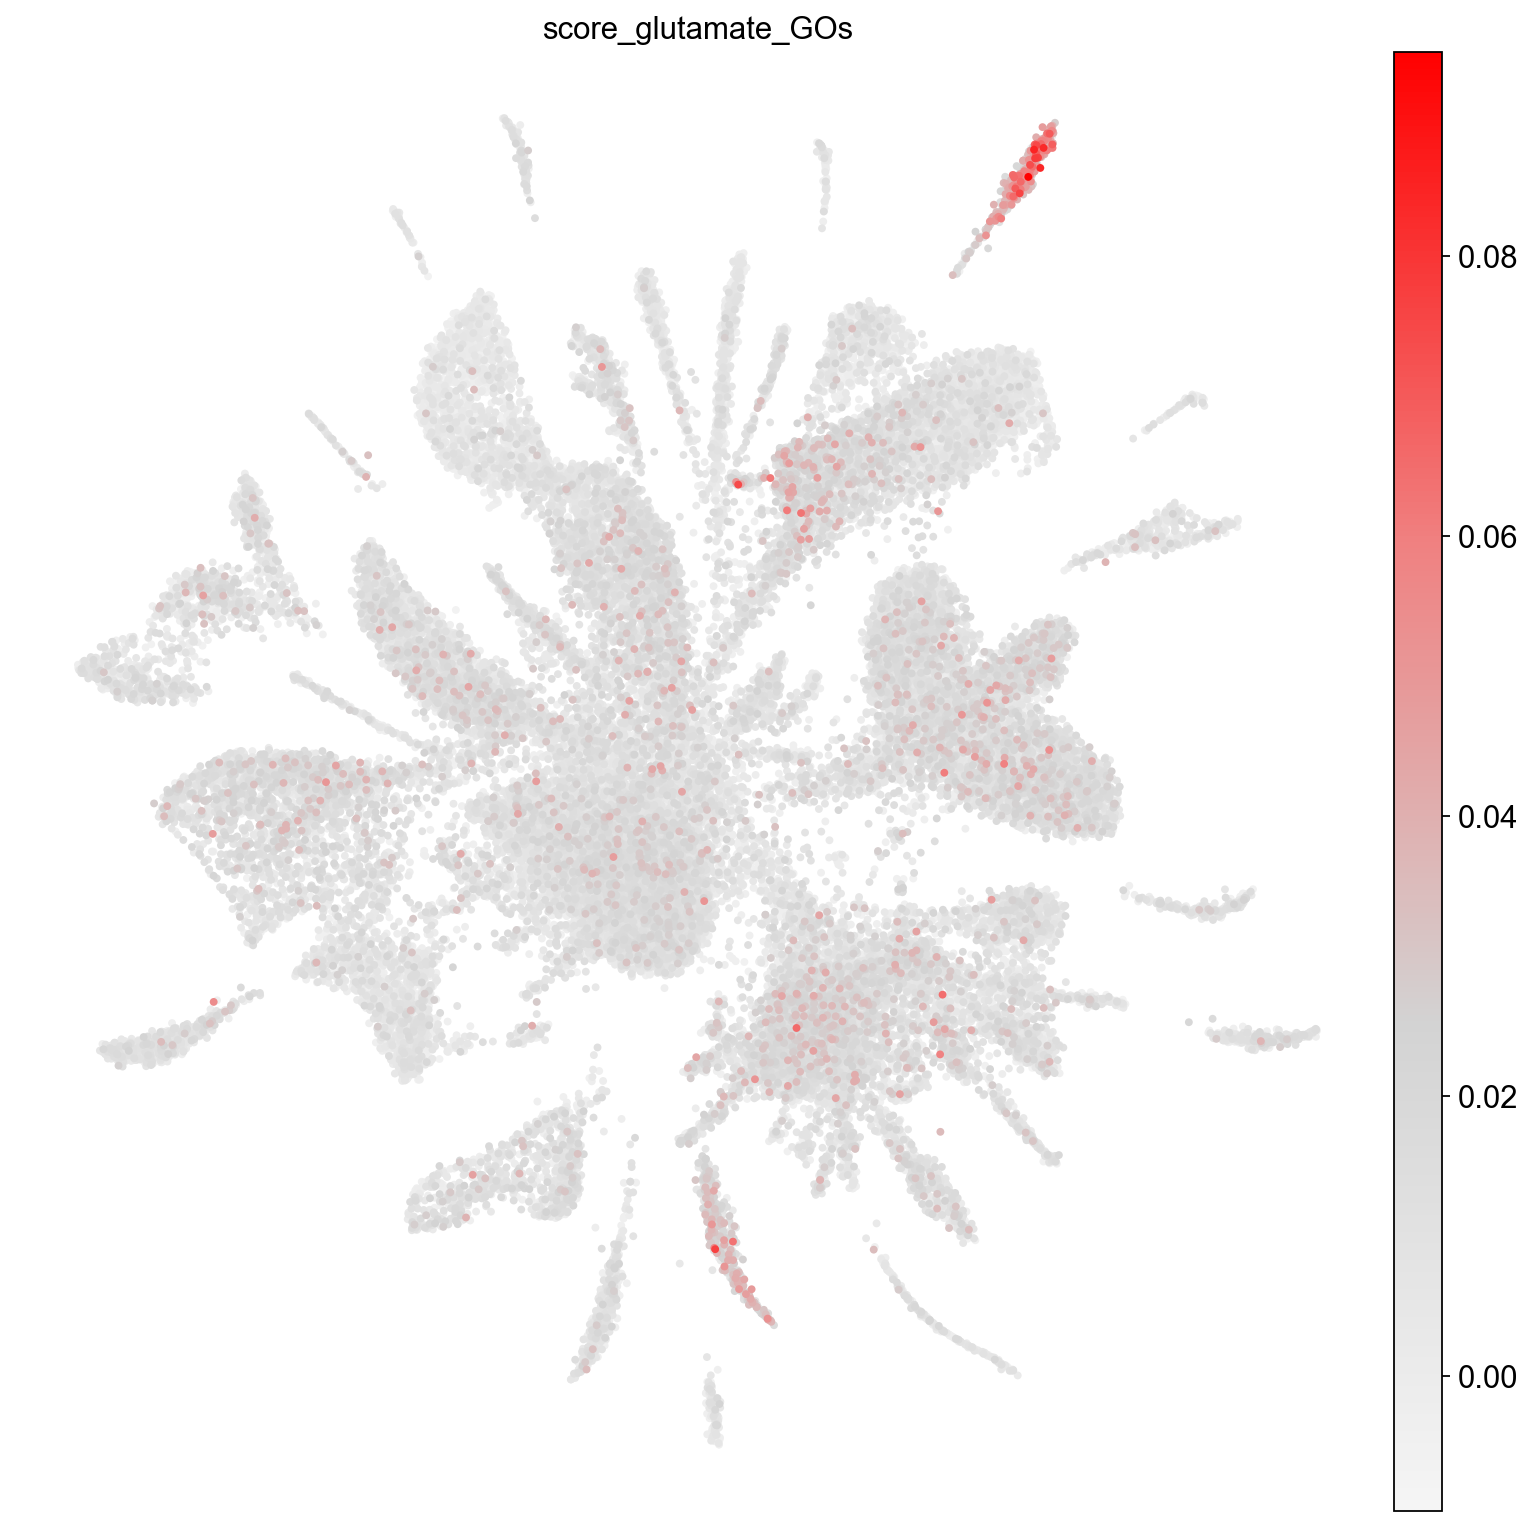

In [ ]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color= 'score_glutamate_GOs', color_map = score_cmap, size = 50, frameon = False, save = 'glutamate_GOs_Score')

In [ ]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names,score_glutamate_GOs
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal,0.016395
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.006191
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts,0.005713
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,4,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal,0.005794
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle,0.004640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,7,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal,-0.003038
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,0,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts,0.016173
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal,-0.004085
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.018633


In [ ]:
sc_cluster_glutamate = pd.pivot_table(adata.obs[[clusteringlayer, 'score_glutamate_GOs']], index = clusteringlayer)

In [ ]:
sc_cluster_glutamate.index

CategoricalIndex(['neoblasts 1', 'chat+ neurons 1', 'body wall muscle',
                  'intestinal and DV muscle', 'phagocyte progenitors',
                  'neoblasts 3', 'pgrn+ parenchymal cells 2',
                  'pgrn+ parenchymal cells 1', 'late epidermal progenitors',
                  'early epidermal progenitors 1', 'phagocytes', 'neoblasts 2',
                  'muscle pharynx', 'epidermis 1', 'neuronal progenitors',
                  'chat+ neurons 2', 'otf+ neurons 1',
                  'protonephridia flame cells',
                  'early epidermal progenitors 2', 'celsr-1+ neurons',
                  'th+ neurons', 'secretory 1', 'psap+ parenchymal cells',
                  'ldlrr+ parenchymal cells', 'basal cells',
                  'muscle progenitors', 'epidermis 2', 'para+ neurons',
                  'pharynx cell type', 'secretory 2', 'otf+ neurons 2',
                  'germ cell progenitors', 'pigment cells',
                  'protonephridia tubule cells', 

In [ ]:
sc_cluster_glutamate['score_glutamate_GOs']

leiden_3_names
neoblasts 1                 0.005563
chat+ neurons 1             0.007266
body wall muscle            0.007986
intestinal and DV muscle    0.006662
phagocyte progenitors       0.007998
                              ...   
neoblasts 15                0.007558
neoblasts 16                0.004233
unannotated 1               0.008520
unannotated 2               0.002987
unannotated 3               0.006422
Name: score_glutamate_GOs, Length: 74, dtype: float64

In [ ]:
sc_cluster_glutamate

,score_glutamate_GOs
leiden_3_names,
neoblasts 1,0.005563
chat+ neurons 1,0.007266
body wall muscle,0.007986
intestinal and DV muscle,0.006662
phagocyte progenitors,0.007998
...,...
neoblasts 15,0.007558
neoblasts 16,0.004233
unannotated 1,0.008520


# Saving

In [ ]:
sc_cluster_glutamate.to_excel( './sc_cluster_glutamate.xlsx')

**smed_genes_annotated_with_gaba_GOs**

In [ ]:
gaba_GOs = ["h1SMcG0000524",
"h1SMcG0002319",
"h1SMcG0009810",
"h1SMcG0010690",
"h1SMcG0015170",
"h1SMcG0017394",
"h1SMcG0017641",
"h1SMcG0021567",
"h1SMnG0003726",
"h1SMnG0017596"
]

In [ ]:
sc.tl.score_genes(adata, gaba_GOs, ctrl_size= len(gaba_GOs), gene_pool=None, n_bins=25, score_name='score_gaba_GOs')

computing score 'score_gaba_GOs'
    finished: added
    'score_gaba_GOs', score of gene set (adata.obs).
    90 total control genes are used. (0:00:00)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\tools\_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


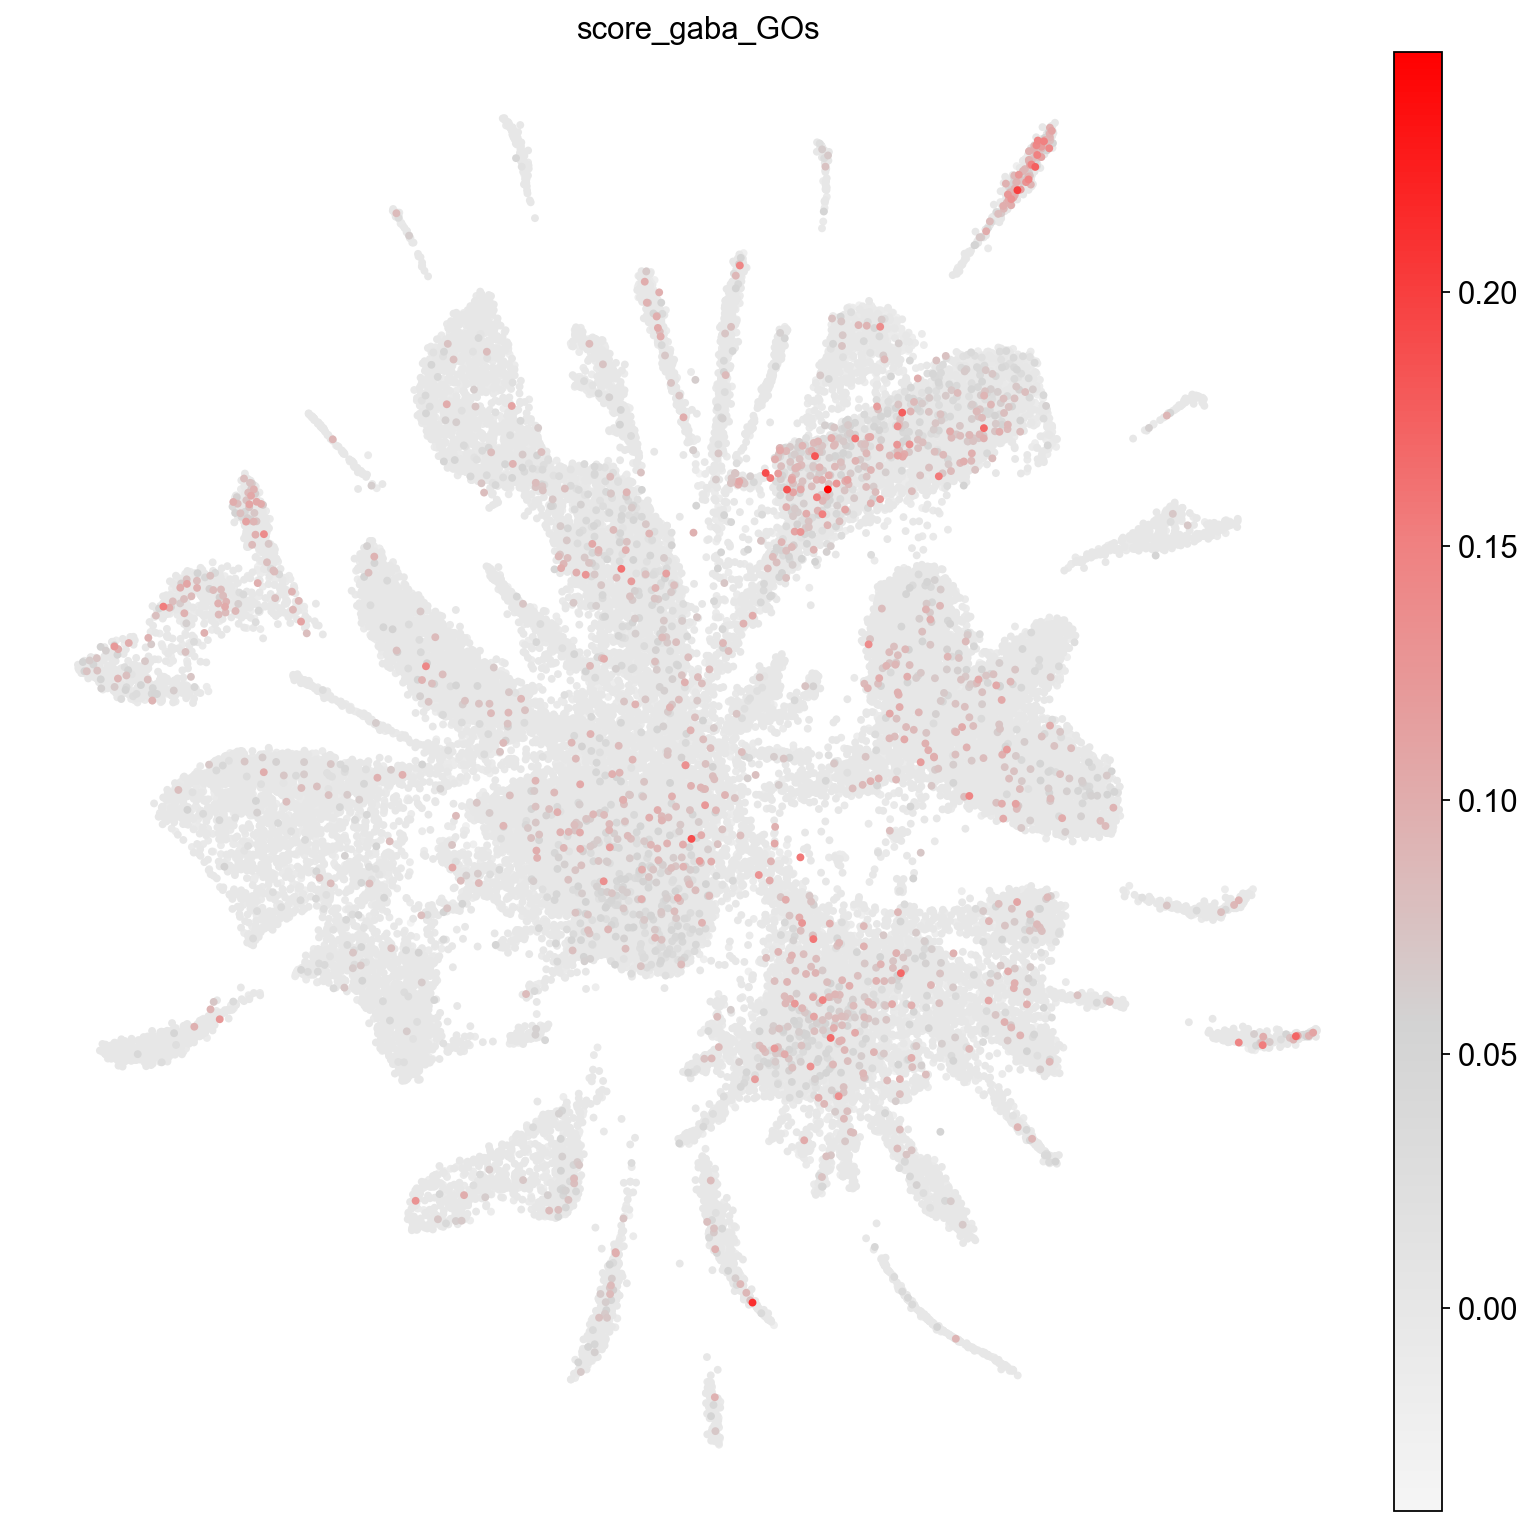

In [ ]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color= 'score_gaba_GOs', color_map = score_cmap, size = 50, frameon = False, save = 'gaba_GOs_Score')

In [ ]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names,score_glutamate_GOs,score_gaba_GOs
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal,0.016395,0.000000
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.006191,0.000000
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts,0.005713,0.030815
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal,0.005794,0.000000
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle,0.004640,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal,-0.003038,0.000000
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts,0.016173,-0.010564
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal,-0.004085,0.000000
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.018633,-0.006978


In [ ]:
sc_cluster_gaba = pd.pivot_table(adata.obs[[clusteringlayer, 'score_gaba_GOs']], index = clusteringlayer)

In [ ]:
sc_cluster_gaba.index

CategoricalIndex(['neoblasts 1', 'chat+ neurons 1', 'body wall muscle',
                  'intestinal and DV muscle', 'phagocyte progenitors',
                  'neoblasts 3', 'pgrn+ parenchymal cells 2',
                  'pgrn+ parenchymal cells 1', 'late epidermal progenitors',
                  'early epidermal progenitors 1', 'phagocytes', 'neoblasts 2',
                  'muscle pharynx', 'epidermis 1', 'neuronal progenitors',
                  'chat+ neurons 2', 'otf+ neurons 1',
                  'protonephridia flame cells',
                  'early epidermal progenitors 2', 'celsr-1+ neurons',
                  'th+ neurons', 'secretory 1', 'psap+ parenchymal cells',
                  'ldlrr+ parenchymal cells', 'basal cells',
                  'muscle progenitors', 'epidermis 2', 'para+ neurons',
                  'pharynx cell type', 'secretory 2', 'otf+ neurons 2',
                  'germ cell progenitors', 'pigment cells',
                  'protonephridia tubule cells', 

In [ ]:
sc_cluster_gaba['score_gaba_GOs']

leiden_3_names
neoblasts 1                 0.000137
chat+ neurons 1            -0.000108
body wall muscle           -0.000035
intestinal and DV muscle    0.000658
phagocyte progenitors       0.001553
                              ...   
neoblasts 15               -0.000498
neoblasts 16               -0.001763
unannotated 1               0.001741
unannotated 2              -0.004345
unannotated 3              -0.002339
Name: score_gaba_GOs, Length: 74, dtype: float64

In [ ]:
sc_cluster_gaba

,score_gaba_GOs
leiden_3_names,
neoblasts 1,0.000137
chat+ neurons 1,-0.000108
body wall muscle,-0.000035
intestinal and DV muscle,0.000658
phagocyte progenitors,0.001553
...,...
neoblasts 15,-0.000498
neoblasts 16,-0.001763
unannotated 1,0.001741


# Saving

In [ ]:
sc_cluster_gaba.to_excel( './sc_cluster_gaba.xlsx')

**smed_genes_annotated_with_choline_GOs**

In [ ]:
choline_GOs = ["h1SMcG0000180",
"h1SMcG0000193",
"h1SMcG0000195",
"h1SMcG0000759",
"h1SMcG0000890",
"h1SMcG0001346",
"h1SMcG0001447",
"h1SMcG0001826",
"h1SMcG0001951",
"h1SMcG0002162",
"h1SMcG0002341",
"h1SMcG0002369",
"h1SMcG0002370",
"h1SMcG0002371",
"h1SMcG0002372",
"h1SMcG0003461",
"h1SMcG0003574",
"h1SMcG0003657",
"h1SMcG0003703",
"h1SMcG0004157",
"h1SMcG0004241",
"h1SMcG0007578",
"h1SMcG0007585",
"h1SMcG0007641",
"h1SMcG0007647",
"h1SMcG0008124",
"h1SMcG0008184",
"h1SMcG0008371",
"h1SMcG0008988",
"h1SMcG0009545",
"h1SMcG0010125",
"h1SMcG0010495",
"h1SMcG0010639",
"h1SMcG0011085",
"h1SMcG0011117",
"h1SMcG0013059",
"h1SMcG0013061",
"h1SMcG0013190",
"h1SMcG0013299",
"h1SMcG0013358",
"h1SMcG0014386",
"h1SMcG0014622",
"h1SMcG0014987",
"h1SMcG0015024",
"h1SMcG0015027",
"h1SMcG0015771",
"h1SMcG0016221",
"h1SMcG0016343",
"h1SMcG0017625",
"h1SMcG0017674",
"h1SMcG0018291",
"h1SMcG0018298",
"h1SMcG0018732",
"h1SMcG0018754",
"h1SMcG0018756",
"h1SMcG0018832",
"h1SMcG0019434",
"h1SMcG0019791",
"h1SMcG0020470",
"h1SMcG0020471",
"h1SMcG0020472",
"h1SMcG0021819",
"h1SMcG0022547",
"h1SMnG0000304",
"h1SMnG0003188",
"h1SMnG0006085",
"h1SMnG0012873",
"h1SMnG0024514"
]

In [ ]:
sc.tl.score_genes(adata, choline_GOs, ctrl_size= len(choline_GOs), gene_pool=None, n_bins=25, score_name='score_choline_GOs')

computing score 'score_choline_GOs'
    finished: added
    'score_choline_GOs', score of gene set (adata.obs).
    1086 total control genes are used. (0:00:00)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\tools\_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


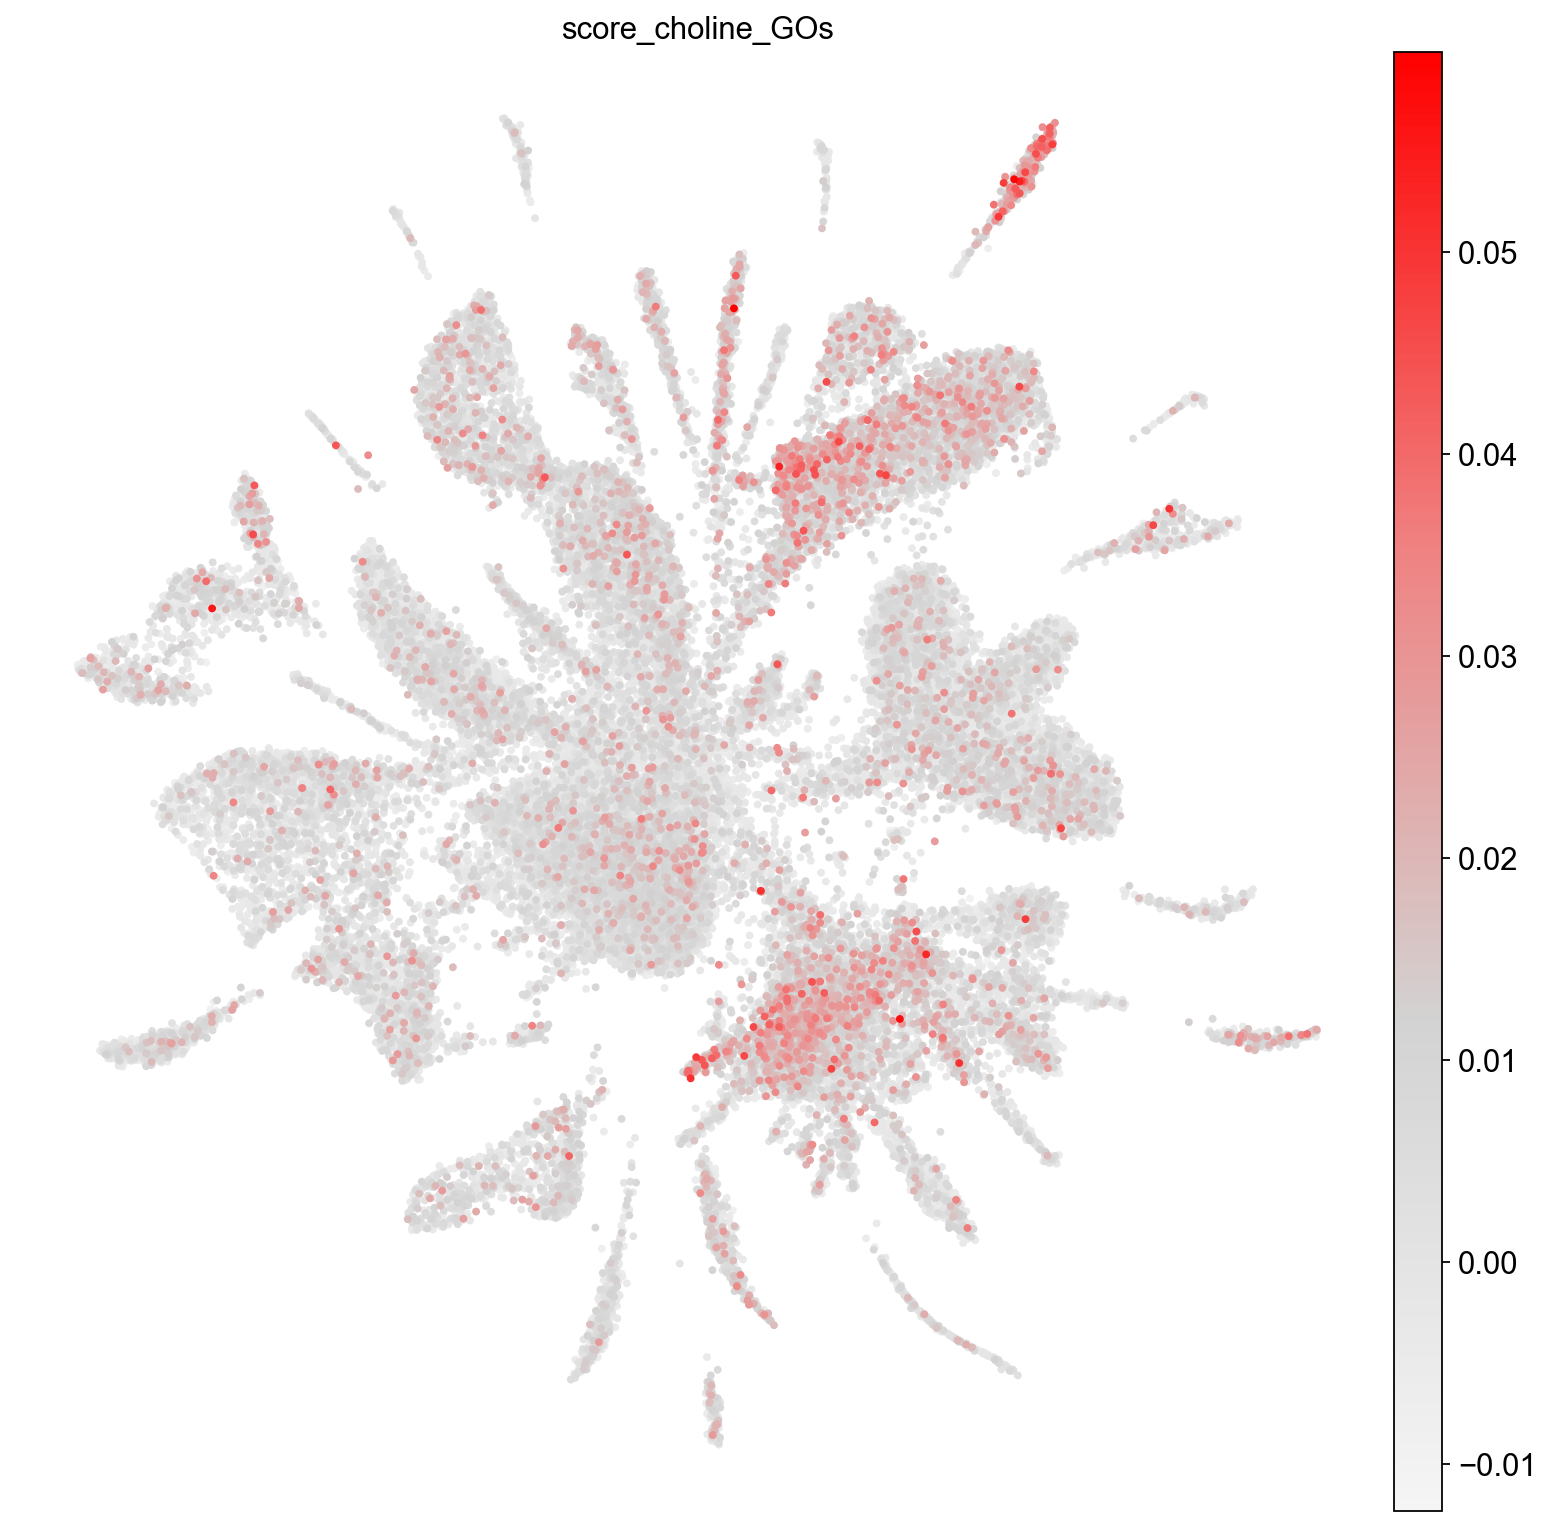

In [ ]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color= 'score_choline_GOs', color_map = score_cmap, size = 50, frameon = False, save = 'choline_GO_Score')

In [ ]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names,score_glutamate_GOs,score_gaba_GOs,score_choline_GOs
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal,0.016395,0.000000,0.006025
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.006191,0.000000,-0.005427
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts,0.005713,0.030815,-0.005344
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal,0.005794,0.000000,-0.002775
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle,0.004640,0.000000,-0.002122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal,-0.003038,0.000000,0.008749
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts,0.016173,-0.010564,-0.003229
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal,-0.004085,0.000000,-0.001955
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.018633,-0.006978,-0.003244


In [ ]:
sc_cluster_choline = pd.pivot_table(adata.obs[[clusteringlayer, 'score_choline_GOs']], index = clusteringlayer)

In [ ]:
sc_cluster_choline.index

CategoricalIndex(['neoblasts 1', 'chat+ neurons 1', 'body wall muscle',
                  'intestinal and DV muscle', 'phagocyte progenitors',
                  'neoblasts 3', 'pgrn+ parenchymal cells 2',
                  'pgrn+ parenchymal cells 1', 'late epidermal progenitors',
                  'early epidermal progenitors 1', 'phagocytes', 'neoblasts 2',
                  'muscle pharynx', 'epidermis 1', 'neuronal progenitors',
                  'chat+ neurons 2', 'otf+ neurons 1',
                  'protonephridia flame cells',
                  'early epidermal progenitors 2', 'celsr-1+ neurons',
                  'th+ neurons', 'secretory 1', 'psap+ parenchymal cells',
                  'ldlrr+ parenchymal cells', 'basal cells',
                  'muscle progenitors', 'epidermis 2', 'para+ neurons',
                  'pharynx cell type', 'secretory 2', 'otf+ neurons 2',
                  'germ cell progenitors', 'pigment cells',
                  'protonephridia tubule cells', 

In [ ]:
sc_cluster_choline['score_choline_GOs']

leiden_3_names
neoblasts 1                -0.000430
chat+ neurons 1             0.003779
body wall muscle            0.000124
intestinal and DV muscle   -0.000662
phagocyte progenitors       0.001930
                              ...   
neoblasts 15                0.000354
neoblasts 16                0.001890
unannotated 1              -0.001107
unannotated 2               0.000869
unannotated 3              -0.002103
Name: score_choline_GOs, Length: 74, dtype: float64

In [ ]:
sc_cluster_choline

,score_choline_GOs
leiden_3_names,
neoblasts 1,-0.000430
chat+ neurons 1,0.003779
body wall muscle,0.000124
intestinal and DV muscle,-0.000662
phagocyte progenitors,0.001930
...,...
neoblasts 15,0.000354
neoblasts 16,0.001890
unannotated 1,-0.001107


# Saving

In [ ]:
sc_cluster_glutamate.to_excel( './sc_cluster_choline.xlsx')

**smed_genes_annotated_with_amine_GOs**

In [ ]:
amine_GOs = ["h1SMcG0000075",
"h1SMcG0000219",
"h1SMcG0000227",
"h1SMcG0000228",
"h1SMcG0000229",
"h1SMcG0000485",
"h1SMcG0000518",
"h1SMcG0000639",
"h1SMcG0000646",
"h1SMcG0000648",
"h1SMcG0000652",
"h1SMcG0000653",
"h1SMcG0000658",
"h1SMcG0000662",
"h1SMcG0000870",
"h1SMcG0000904",
"h1SMcG0000906",
"h1SMcG0000954",
"h1SMcG0000989",
"h1SMcG0001077",
"h1SMcG0001236",
"h1SMcG0001325",
"h1SMcG0001346",
"h1SMcG0001542",
"h1SMcG0001543",
"h1SMcG0001741",
"h1SMcG0001890",
"h1SMcG0002048",
"h1SMcG0002078",
"h1SMcG0002311",
"h1SMcG0002319",
"h1SMcG0002382",
"h1SMcG0002573",
"h1SMcG0003011",
"h1SMcG0003178",
"h1SMcG0003196",
"h1SMcG0003214",
"h1SMcG0003284",
"h1SMcG0003461",
"h1SMcG0003493",
"h1SMcG0003532",
"h1SMcG0003533",
"h1SMcG0003595",
"h1SMcG0003612",
"h1SMcG0003634",
"h1SMcG0003703",
"h1SMcG0003705",
"h1SMcG0003707",
"h1SMcG0003818",
"h1SMcG0003850",
"h1SMcG0004047",
"h1SMcG0004060",
"h1SMcG0004256",
"h1SMcG0004312",
"h1SMcG0004313",
"h1SMcG0004314",
"h1SMcG0004315",
"h1SMcG0004442",
"h1SMcG0004448",
"h1SMcG0004449",
"h1SMcG0004450",
"h1SMcG0004459",
"h1SMcG0004514",
"h1SMcG0004543",
"h1SMcG0004563",
"h1SMcG0004882",
"h1SMcG0004947",
"h1SMcG0004988",
"h1SMcG0005219",
"h1SMcG0005297",
"h1SMcG0005306",
"h1SMcG0005328",
"h1SMcG0005337",
"h1SMcG0005340",
"h1SMcG0005350",
"h1SMcG0005351",
"h1SMcG0005356",
"h1SMcG0005525",
"h1SMcG0005735",
"h1SMcG0005775",
"h1SMcG0005856",
"h1SMcG0005862",
"h1SMcG0005933",
"h1SMcG0005934",
"h1SMcG0005940",
"h1SMcG0006077",
"h1SMcG0006297",
"h1SMcG0006353",
"h1SMcG0006473",
"h1SMcG0006635",
"h1SMcG0006695",
"h1SMcG0006969",
"h1SMcG0007060",
"h1SMcG0007105",
"h1SMcG0007106",
"h1SMcG0007108",
"h1SMcG0007206",
"h1SMcG0007431",
"h1SMcG0007578",
"h1SMcG0007585",
"h1SMcG0007606",
"h1SMcG0007645",
"h1SMcG0007668",
"h1SMcG0007671",
"h1SMcG0007672",
"h1SMcG0008123",
"h1SMcG0008200",
"h1SMcG0008296",
"h1SMcG0008434",
"h1SMcG0008491",
"h1SMcG0008641",
"h1SMcG0008877",
"h1SMcG0009023",
"h1SMcG0009255",
"h1SMcG0009256",
"h1SMcG0009460",
"h1SMcG0009466",
"h1SMcG0009960",
"h1SMcG0010058",
"h1SMcG0010198",
"h1SMcG0010289",
"h1SMcG0010345",
"h1SMcG0010398",
"h1SMcG0010432",
"h1SMcG0010495",
"h1SMcG0010517",
"h1SMcG0010614",
"h1SMcG0010639",
"h1SMcG0010691",
"h1SMcG0010723",
"h1SMcG0010724",
"h1SMcG0010915",
"h1SMcG0011090",
"h1SMcG0011153",
"h1SMcG0011319",
"h1SMcG0011327",
"h1SMcG0011433",
"h1SMcG0011441",
"h1SMcG0011524",
"h1SMcG0011558",
"h1SMcG0011606",
"h1SMcG0011735",
"h1SMcG0011740",
"h1SMcG0011764",
"h1SMcG0012113",
"h1SMcG0012147",
"h1SMcG0012533",
"h1SMcG0012648",
"h1SMcG0012721",
"h1SMcG0012736",
"h1SMcG0012763",
"h1SMcG0012986",
"h1SMcG0013034",
"h1SMcG0013119",
"h1SMcG0013264",
"h1SMcG0013268",
"h1SMcG0013273",
"h1SMcG0013279",
"h1SMcG0013299",
"h1SMcG0013334",
"h1SMcG0013358",
"h1SMcG0013526",
"h1SMcG0013766",
"h1SMcG0013792",
"h1SMcG0013881",
"h1SMcG0014000",
"h1SMcG0014145",
"h1SMcG0014150",
"h1SMcG0014164",
"h1SMcG0014386",
"h1SMcG0014509",
"h1SMcG0014535",
"h1SMcG0014666",
"h1SMcG0014987",
"h1SMcG0015024",
"h1SMcG0015027",
"h1SMcG0015329",
"h1SMcG0015352",
"h1SMcG0015757",
"h1SMcG0015771",
"h1SMcG0015790",
"h1SMcG0016221",
"h1SMcG0016247",
"h1SMcG0016248",
"h1SMcG0016343",
"h1SMcG0016621",
"h1SMcG0016738",
"h1SMcG0016841",
"h1SMcG0016926",
"h1SMcG0016928",
"h1SMcG0016964",
"h1SMcG0016984",
"h1SMcG0017484",
"h1SMcG0017508",
"h1SMcG0017547",
"h1SMcG0017612",
"h1SMcG0017880",
"h1SMcG0018039",
"h1SMcG0018210",
"h1SMcG0018398",
"h1SMcG0018710",
"h1SMcG0018711",
"h1SMcG0018832",
"h1SMcG0019207",
"h1SMcG0019223",
"h1SMcG0019268",
"h1SMcG0019427",
"h1SMcG0019443",
"h1SMcG0019456",
"h1SMcG0019484",
"h1SMcG0019624",
"h1SMcG0019646",
"h1SMcG0020024",
"h1SMcG0020090",
"h1SMcG0020315",
"h1SMcG0020399",
"h1SMcG0020432",
"h1SMcG0020440",
"h1SMcG0020441",
"h1SMcG0020443",
"h1SMcG0020445",
"h1SMcG0020446",
"h1SMcG0020447",
"h1SMcG0020449",
"h1SMcG0020458",
"h1SMcG0020470",
"h1SMcG0020471",
"h1SMcG0020472",
"h1SMcG0020573",
"h1SMcG0020602",
"h1SMcG0020636",
"h1SMcG0020742",
"h1SMcG0020798",
"h1SMcG0020927",
"h1SMcG0021033",
"h1SMcG0021172",
"h1SMcG0021173",
"h1SMcG0021339",
"h1SMcG0021502",
"h1SMcG0021560",
"h1SMcG0021567",
"h1SMcG0021770",
"h1SMcG0021839",
"h1SMcG0022111",
"h1SMcG0022281",
"h1SMcG0022338",
"h1SMcG0022351",
"h1SMcG0022375",
"h1SMcG0022449",
"h1SMcG0022504",
"h1SMcG0022505",
"h1SMcG0022527",
"h1SMcG0022554",
"h1SMcG0022589",
"h1SMcG0022709",
"h1SMcG0022895",
"h1SMcG0022994",
"h1SMcG0023019",
"h1SMcG0023031",
"h1SMcG0023032",
"h1SMcG0023037",
"h1SMnG0001409",
"h1SMnG0001550",
"h1SMnG0003087",
"h1SMnG0003726",
"h1SMnG0006085",
"h1SMnG0008938",
"h1SMnG0009032",
"h1SMnG0009042",
"h1SMnG0011868",
"h1SMnG0012862",
"h1SMnG0022536",
"h1SMnG0023190",
"h1SMnG0024514",
"h1SMnG0025641",
"h1SMnG0032237",
"h1SMnG0032243",
"h1SMnG0033548",
"h1SMnG0034621"
]

In [ ]:
sc.tl.score_genes(adata, amine_GOs, ctrl_size= len(amine_GOs), gene_pool=None, n_bins=25, score_name='score_amine_GOs')

computing score 'score_amine_GOs'
    finished: added
    'score_amine_GOs', score of gene set (adata.obs).
    6652 total control genes are used. (0:00:00)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\tools\_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


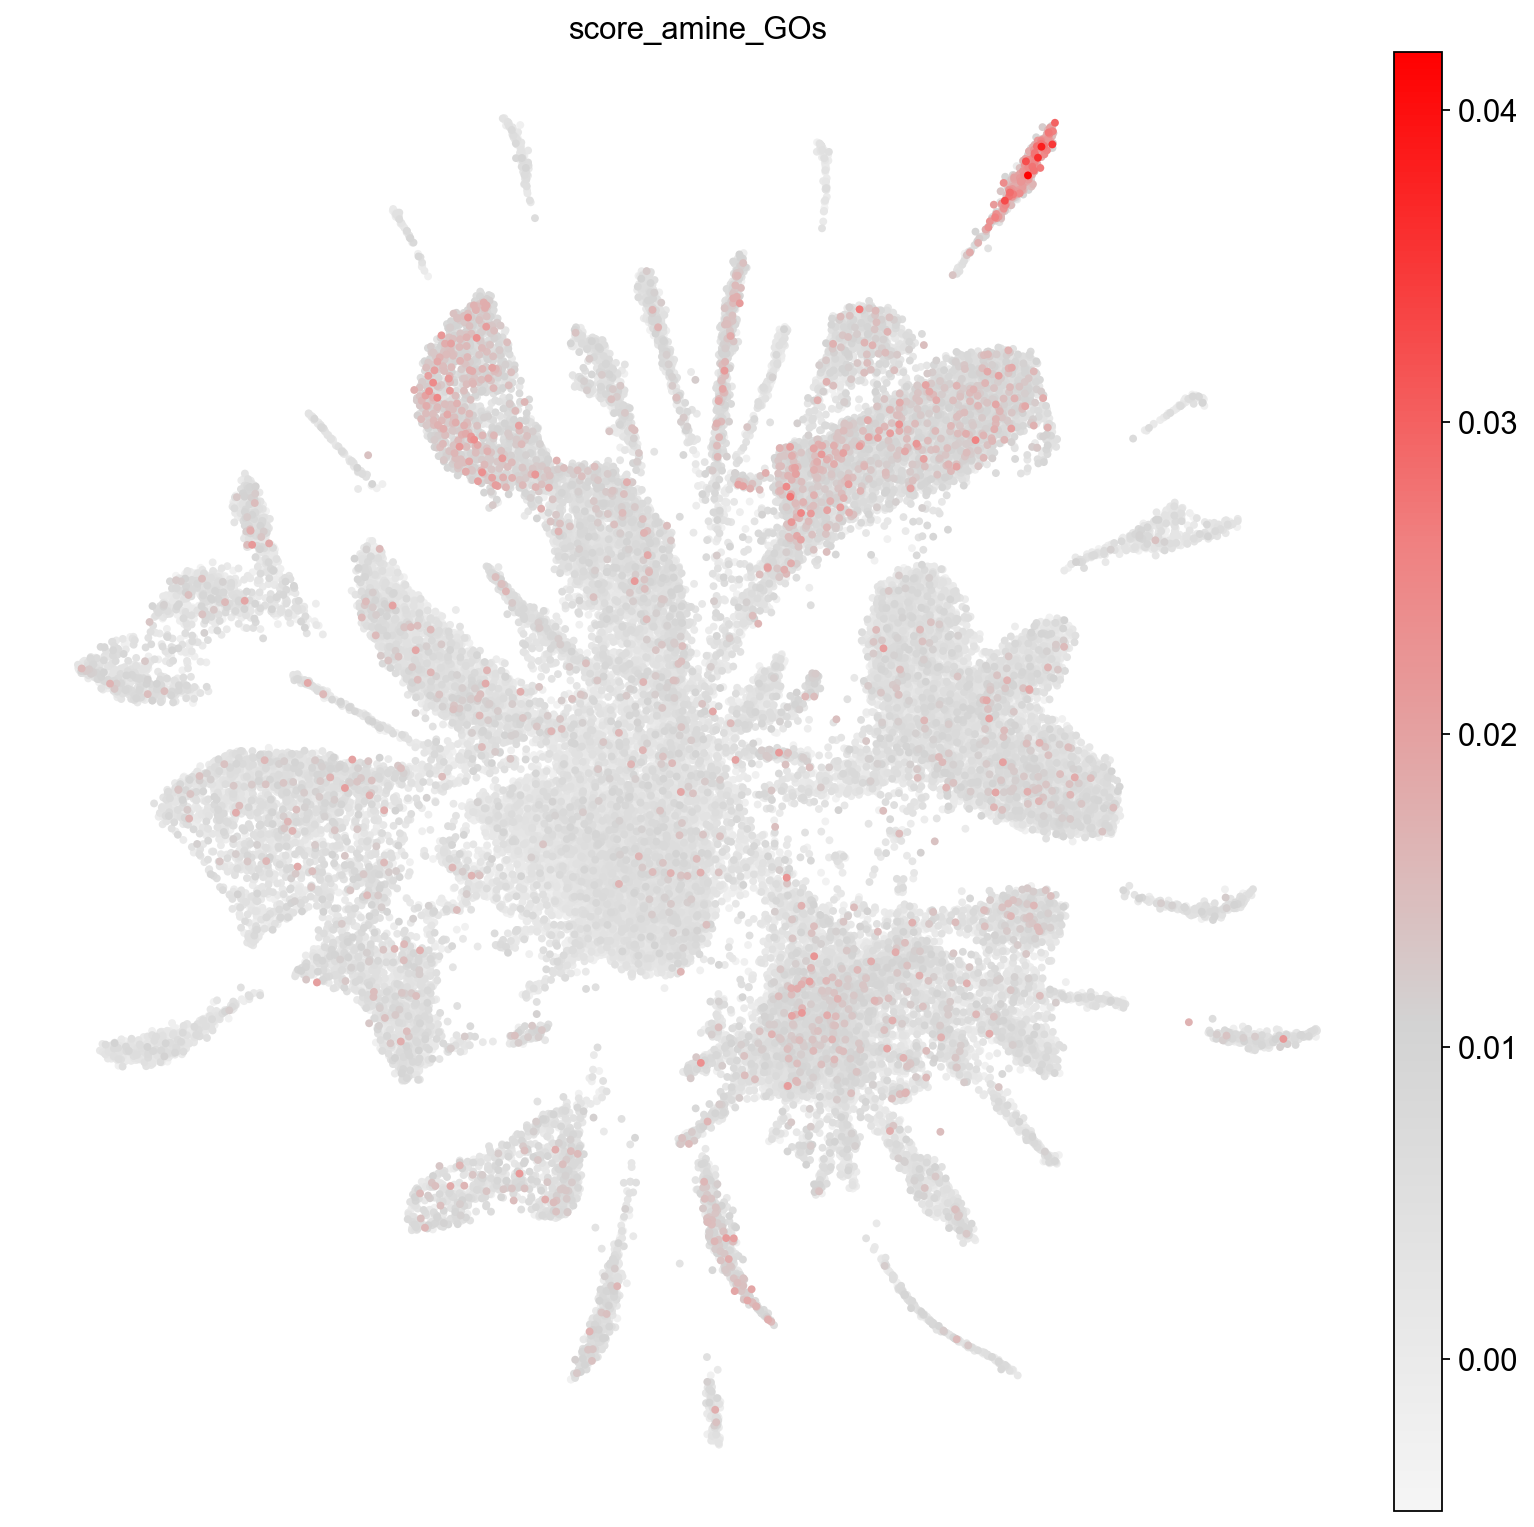

In [ ]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color= 'score_amine_GOs', color_map = score_cmap, size = 50, frameon = False, save = 'amine_GO_Score')

In [ ]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names,score_glutamate_GOs,score_gaba_GOs,score_choline_GOs,score_amine_GOs
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal,0.016395,0.000000,0.006025,0.008605
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.006191,0.000000,-0.005427,0.000224
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts,0.005713,0.030815,-0.005344,0.002356
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal,0.005794,0.000000,-0.002775,0.003390
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle,0.004640,0.000000,-0.002122,0.002045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal,-0.003038,0.000000,0.008749,0.000030
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts,0.016173,-0.010564,-0.003229,-0.002570
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal,-0.004085,0.000000,-0.001955,0.000078
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.018633,-0.006978,-0.003244,0.001794


In [ ]:
sc_cluster_amine = pd.pivot_table(adata.obs[[clusteringlayer, 'score_amine_GOs']], index = clusteringlayer)

In [ ]:
sc_cluster_amine.index

CategoricalIndex(['neoblasts 1', 'chat+ neurons 1', 'body wall muscle',
                  'intestinal and DV muscle', 'phagocyte progenitors',
                  'neoblasts 3', 'pgrn+ parenchymal cells 2',
                  'pgrn+ parenchymal cells 1', 'late epidermal progenitors',
                  'early epidermal progenitors 1', 'phagocytes', 'neoblasts 2',
                  'muscle pharynx', 'epidermis 1', 'neuronal progenitors',
                  'chat+ neurons 2', 'otf+ neurons 1',
                  'protonephridia flame cells',
                  'early epidermal progenitors 2', 'celsr-1+ neurons',
                  'th+ neurons', 'secretory 1', 'psap+ parenchymal cells',
                  'ldlrr+ parenchymal cells', 'basal cells',
                  'muscle progenitors', 'epidermis 2', 'para+ neurons',
                  'pharynx cell type', 'secretory 2', 'otf+ neurons 2',
                  'germ cell progenitors', 'pigment cells',
                  'protonephridia tubule cells', 

In [ ]:
sc_cluster_amine['score_amine_GOs']

leiden_3_names
neoblasts 1                 0.001159
chat+ neurons 1             0.002925
body wall muscle            0.002581
intestinal and DV muscle    0.001793
phagocyte progenitors       0.003367
                              ...   
neoblasts 15                0.001771
neoblasts 16                0.000291
unannotated 1               0.002297
unannotated 2               0.003112
unannotated 3               0.002305
Name: score_amine_GOs, Length: 74, dtype: float64

In [ ]:
sc_cluster_amine

,score_amine_GOs
leiden_3_names,
neoblasts 1,0.001159
chat+ neurons 1,0.002925
body wall muscle,0.002581
intestinal and DV muscle,0.001793
phagocyte progenitors,0.003367
...,...
neoblasts 15,0.001771
neoblasts 16,0.000291
unannotated 1,0.002297


# Saving

In [ ]:
sc_cluster_amine.to_excel( './sc_cluster_amine.xlsx')

In [ ]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names,score_glutamate_GOs,score_gaba_GOs,score_choline_GOs,score_amine_GOs
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal,0.016395,0.000000,0.006025,0.008605
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.006191,0.000000,-0.005427,0.000224
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts,0.005713,0.030815,-0.005344,0.002356
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal,0.005794,0.000000,-0.002775,0.003390
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle,0.004640,0.000000,-0.002122,0.002045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal,-0.003038,0.000000,0.008749,0.000030
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts,0.016173,-0.010564,-0.003229,-0.002570
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal,-0.004085,0.000000,-0.001955,0.000078
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.018633,-0.006978,-0.003244,0.001794


In [ ]:
identities_scored_NT_GOs = adata.obs

In [ ]:
identities_scored_NT_GOs.to_csv("./06092023_smed_sero_identities_scored_NT_GOs.csv")